# Construindo Seu Primeiro Classificador de Imagens

Neste laboratório prático, onde você irá construir, treinar e avaliar seu primeiro classificador de imagens usando o PyTorch! Você já aprendeu os conceitos fundamentais por trás do fluxo de trabalho (*pipeline*) de *deep learning*, e agora é hora de colocar esse conhecimento em prática. Seu objetivo agora é criar uma rede neural capaz de reconhecer dígitos manuscritos do **conjunto de dados MNIST**.



Ao final deste notebook, você terá passado por todo o processo de ponta a ponta. Especificamente, você irá:

* **Preparar seus dados:** Carregar o conjunto de dados MNIST, inspecionar seu formato e aplicar transformações essenciais.
* **Construir seu modelo:** Definir uma rede neural personalizada usando a flexível classe `nn.Module` do PyTorch.
* **Treinar seu modelo:** Implementar o processo completo de treinamento com uma função de perda (*loss function*), otimizador e o laço de treinamento (*training loop*).
* **Analisar seus resultados:** Avaliar seu modelo em dados não vistos e visualizar seu desempenho.

## Importação de Bibliotecas

In [1]:
import os
if not os.path.exists('helper_utils_1.py'):
    !wget -q https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/helper_utils_1.py -O helper_utils_3.py

In [2]:
import numpy as np  # Biblioteca fundamental para computação numérica e manipulação de arrays

import torch        # Biblioteca principal do PyTorch para tensores e redes neurais
import torch.nn as nn  # Módulo que contém as camadas de redes neurais (convolucionais, lineares, etc.)
import torch.optim as optim  # Contém os algoritmos de otimização (Adam, SGD, etc.)
import torchvision  # Biblioteca voltada para Visão Computacional integrada ao PyTorch
import torchvision.transforms as transforms  # Ferramentas para transformar e tratar imagens (redimensionar, normalizar)
from torch.utils.data import DataLoader  # Utilitário para gerenciar o carregamento de dados em lotes (batches)
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos e visualização de dados

import helper_utils_3  # Módulo local/customizado contendo funções auxiliares para o projeto

* O código abaixo seleciona o melhor hardware disponível no seu sistema para acelerar o treinamento do modelo.
    * **CUDA**: Executa em GPUs da NVIDIA, que são amplamente utilizadas para *deep learning* e geralmente oferecem o desempenho de treinamento mais rápido.
    * **MPS**: Executa em GPUs Apple Silicon, proporcionando aceleração eficiente em sistemas Mac modernos.
    * **CPU**: Executa na Unidade Central de Processamento, o processador padrão que todo computador possui. O PyTorch a utilizará automaticamente se nenhuma GPU compatível for detectada.

In [3]:
# Verifica se uma GPU NVIDIA está disponível via drivers CUDA
if torch.cuda.is_available():
    # Define o dispositivo como CUDA (NVIDIA GPU)
    device = torch.device("cuda")
    print(f"Usando o dispositivo: CUDA")

# Caso não haja CUDA, verifica se é um Mac com chip Apple Silicon (M1, M2, M3, etc.)
# O backend MPS (Metal Performance Shaders) permite usar a GPU integrada da Apple
elif torch.backends.mps.is_available():
    # Define o dispositivo como MPS
    device = torch.device("mps")
    print(f"Usando o dispositivo: MPS (Apple Silicon GPU)")

# Se nenhuma aceleração de hardware for encontrada, utiliza o processador principal (CPU)
else:
    # Define o dispositivo padrão como CPU
    device = torch.device("cpu")
    print(f"Usando o dispositivo: CPU")

Usando o dispositivo: CUDA


## Conjunto de Dados MNIST: Preparando seus Dados

O [conjunto de dados MNIST](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) é um benchmark clássico para classificação de imagens e é frequentemente considerado o "hello world" da visão computacional. Ele contém 60.000 imagens de treinamento e 10.000 imagens de teste. Cada imagem possui 28 por 28 pixels, em tons de cinza, exibindo um único dígito manuscrito de 0 a 9.



Antes que um modelo possa aprender com esses dados, você precisa converter as imagens em números que uma rede neural possa processar. Cada pixel torna-se um valor numérico que representa seu brilho e, juntos, esses números formam um **tensor**, que é o formato utilizado pelos modelos do PyTorch para computação. As redes neurais treinam melhor quando esses valores de entrada são pequenos e centrados em torno de zero, pois isso ajuda os gradientes a fluírem com mais facilidade e torna o aprendizado mais estável. Para conseguir isso, você irá **normalizar** os valores dos pixels para que eles fiquem dentro dessa faixa.



Para ver exatamente o que isso significa, você começará carregando os dados de treinamento do MNIST diretamente da `torchvision`, a biblioteca do PyTorch para tarefas de visão computacional. Você não aplicará nenhuma transformação ainda. Em vez disso, inspecionará uma imagem bruta para ver como os dados se parecem antes de qualquer alteração e, posteriormente, comparará como essa mesma imagem aparece uma vez preparada para o modelo.

* Defina `data_path`, que especifica a pasta onde seu conjunto de dados será armazenado.

In [4]:
# Define o caminho (diretório) onde os arquivos do conjunto de dados serão armazenados
data_path = "./data"

* Carregue o conjunto de dados MNIST usando [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html).
    * `root`: Isso informa ao PyTorch onde salvar os arquivos do conjunto de dados. Neste caso, no local do `data_path` que você acabou de definir.
    * `train`: Definir isso como `True` garante que você obtenha a divisão de treinamento do conjunto de dados, que contém 60.000 imagens.
    * `download`: Este parâmetro prático instrui o PyTorch a baixar automaticamente os arquivos caso eles ainda não estejam presentes na sua pasta raiz.

In [5]:
# Carrega o conjunto de dados MNIST (dígitos escritos à mão) sem aplicar transformações iniciais
train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path,     # Caminho para o diretório onde os dados estão ou serão armazenados
    train=True,         # Especifica que você deseja carregar a divisão de TREINO do dataset
    download=True       # Baixa os dados automaticamente da internet caso não sejam encontrados na pasta 'root'
)

Agora que você carregou o conjunto de dados, pode inspecionar um item individual dele.

* Você pode recuperar qualquer amostra do seu objeto `Dataset` como se fosse uma lista de Python, utilizando seu índice. Aqui, você acessará o primeiro item no índice `0`.
* Observe que cada item é uma **tupla** contendo duas partes: os dados da imagem e seu rótulo numérico correspondente.
* Após executar o código, você deverá ver o seguinte:
    * A imagem é um objeto **PIL Image**, um formato comum de Python para dados de imagem.
    * Suas dimensões são **(28, 28)**, o que corresponde ao tamanho das imagens do MNIST.
    * O rótulo é um número inteiro que representa o dígito exibido na imagem.



> **Uma Nota sobre Rótulos**: 
>
> Os conjuntos de dados no PyTorch retornam rótulos como **índices numéricos**, não como texto. Para o **conjunto de dados MNIST**, isso é direto: o índice `0` representa o dígito `0`, o índice `1` representa o dígito `1`, e assim por diante.
>
> Essa relação entre índices de rótulos e seus significados é menos direta em outros conjuntos de dados. Por exemplo, se você estivesse trabalhando com imagens de gatos e cachorros, os rótulos ainda seriam 0 e 1, não as palavras "gato" ou "cachorro". Nesses casos, você poderia criar uma lista como `class_names = ['gato', 'cachorro']` para mapear os índices numéricos de volta para nomes legíveis ao exibir resultados ou depurar.

In [6]:
# Obtém a primeira amostra (índice 0) do dataset, que retorna uma tupla contendo (imagem, rótulo)
image_pil, label = train_dataset_without_transform[0] # Extrai a imagem e seu respectivo gabarito
    
# Exibe o tipo do objeto da imagem (geralmente uma PIL.Image.Image se nenhuma transformação foi aplicada)
print(f"Tipo da imagem:        {type(image_pil)}")

# Para objetos PIL, usamos o atributo .size para ver a resolução (largura, altura)
# No caso do MNIST, o esperado é (28, 28)
print(f"Dimensões da imagem:  {image_pil.size}")

# Exibe o tipo do rótulo (geralmente um inteiro simples no Python)
print(f"Tipo do rótulo:        {type(label)}")

# Exibe o valor real do rótulo (o dígito que a imagem representa, de 0 a 9)
print(f"Valor do rótulo:       {label}")

Tipo da imagem:        <class 'PIL.Image.Image'>
Dimensões da imagem:  (28, 28)
Tipo do rótulo:        <class 'int'>
Valor do rótulo:       5


#### Visualizando um Dígito Bruto

Agora, você visualizará a imagem bruta que acabou de carregar. A função auxiliar `display_image` mostra a imagem junto com uma grade dos valores numéricos dos pixels.

* Execute a célula de código abaixo para exibir a imagem.
* Observe a barra de cores à direita, que mostra toda a faixa de valores de brilho possíveis para um pixel, de **0** a **255**. É assim que os dados se parecem *antes* de qualquer normalização.
* Cada número sobreposto ao dígito representa o brilho daquele pixel individual. Em uma imagem em tons de cinza, **0** corresponde ao preto puro, **255** ao branco puro, e os valores intermediários são tons de cinza.
    * Você pode tentar executar a função novamente com `show_values=False` para ver a imagem sem a grade numérica.

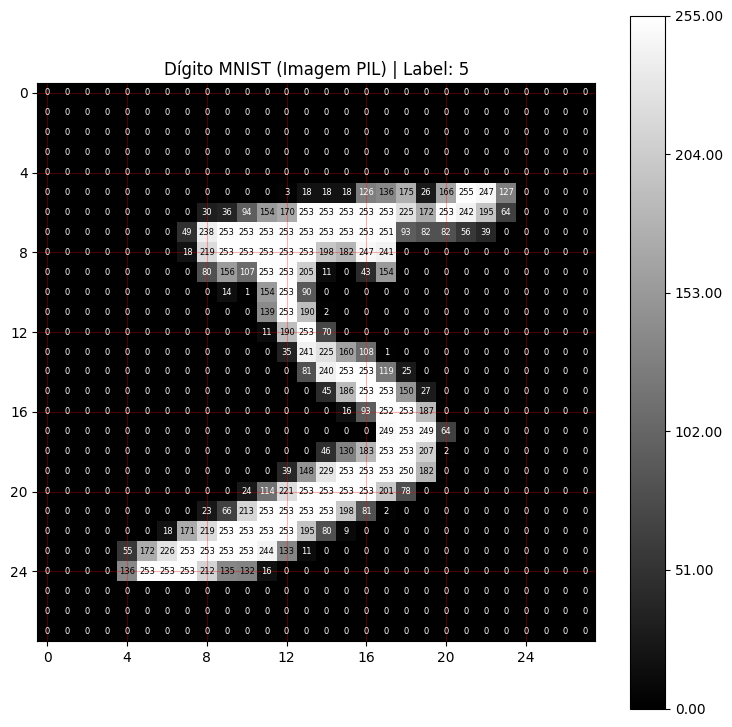

In [7]:
# Visualiza a imagem de exemplo e seu respectivo rótulo (label)
# O parâmetro 'show_values=True' exibe a intensidade numérica de cada pixel (0 a 255)
# facilitando a compreensão de como a imagem é representada matematicamente.
helper_utils_3.display_image(image_pil, label, "Dígito MNIST (Imagem PIL)", show_values=True)

### O Efeito das Transformações

Você já viu os dados brutos: uma **imagem PIL** padrão com valores de pixel variando de 0 a 255. Em seguida, você preparará os dados para o modelo aplicando transformações e verá como essas etapas alteram a estrutura e os valores numéricos da imagem.

#### Transformações

Você usará o [transforms.Compose](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html) para encadear uma sequência de etapas de preparação que são aplicadas a cada imagem conforme ela é carregada. Para esta tarefa, você usará duas das transformações mais comuns:

  * <code>[transforms.ToTensor()](https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html)</code>: Converte a imagem PIL em um tensor do PyTorch e redimensiona os valores de seus pixels da faixa original de 0–255 para valores entre 0 e 1.
  * <code>[transforms.Normalize()](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html)</code>: Ajusta ainda mais os valores do tensor, centrando-os em torno de zero, usando a média e o desvio padrão calculados a partir do conjunto de dados MNIST. Isso torna os dados mais consistentes e ajuda o modelo a aprender de forma mais rápida e confiável.

In [8]:
# Define uma sequência de transformações (pipeline) para os dados
# transforms.Compose permite encadear várias operações em uma única variável
transform = transforms.Compose([
    # Converte a imagem PIL ou array NumPy para um Tensor do PyTorch.
    # Esta operação também redimensiona os valores dos pixels do intervalo [0, 255] para [0, 1].
    transforms.ToTensor(),
    
    # Normaliza o tensor usando a média (mean) e o desvio padrão (std) do dataset MNIST.
    # A fórmula aplicada é: (valor - média) / desvio_padrão.
    # Isso centraliza os dados em torno de 0, facilitando a convergência da rede neural.
    transforms.Normalize((0.1307,), (0.3081,))
])

Agora você carregará o conjunto de dados novamente, desta vez aplicando as transformações que acabou de definir. O código é quase idêntico ao anterior, com uma adição importante.

* O argumento `transform` recebe o objeto `transform` que você criou anteriormente. Isso instrui o `Dataset` a aplicar automaticamente sua sequência de transformações (`ToTensor` e `Normalize`) a cada imagem conforme ela for carregada.

In [9]:
# Carrega o conjunto de dados MNIST de treino, desta vez aplicando o pipeline de transformações
train_dataset = torchvision.datasets.MNIST(
    root=data_path,     # Diretório onde os dados estão ou serão baixados
    train=True,         # Define que queremos carregar especificamente os dados de TREINAMENTO
    download=True,      # Baixa os arquivos automaticamente se não estiverem na pasta local
    transform=transform # Aplica as transformações (ToTensor e Normalize) em cada imagem ao carregá-las
)

Vamos acessar o mesmo item novamente, desta vez a partir do conjunto de dados com as transformações aplicadas. Observe as principais diferenças na saída:

* A imagem não é mais uma "PIL Image", pois a transformação `ToTensor` a converteu em um `torch.Tensor`, o formato exigido pelos modelos do PyTorch.
* O formato (*shape*) agora é `(1, 28, 28)`. O PyTorch estrutura tensores de imagem como `[canais, altura, largura]`. Como as imagens estão em tons de cinza, existe apenas um canal.

In [10]:
# Acessa o primeiro item novamente (agora com as transformações aplicadas)
image_tensor, label = train_dataset[0]

# O tipo agora deve ser torch.Tensor, pronto para ser processado pela rede neural
print(f"Tipo da Imagem:                   {type(image_tensor)}")

# Como a imagem agora é um Tensor do PyTorch, usamos o atributo .shape para ver as dimensões.
# O formato esperado é [C, H, W] -> [Canais, Altura, Largura], ou seja, [1, 28, 28].
print(f"Formato da Imagem Pós-Transformação: {image_tensor.shape}")

# O rótulo permanece como um tipo primitivo (inteiro)
print(f"Tipo do Rótulo:                   {type(label)}")

# O valor numérico que representa a classe da imagem
print(f"Valor do Rótulo:                  {label}")

Tipo da Imagem:                   <class 'torch.Tensor'>
Formato da Imagem Pós-Transformação: torch.Size([1, 28, 28])
Tipo do Rótulo:                   <class 'int'>
Valor do Rótulo:                  5


#### Visualizando um Dígito Transformado

Agora você pode visualizar o mesmo dígito novamente, mas desta vez após as transformações terem sido aplicadas.

* Observe atentamente os valores dos pixels. Eles não estão mais na faixa de 0 a 255. A transformação de normalização (*Normalize*) deslocou esses valores para que agora estejam **centrados em torno de zero**, resultando em uma nova faixa de aproximadamente **-0,42** a **2,82**.
* A barra de cores à direita confirma essa mudança. Pixels que originalmente eram escuros (valores baixos) agora possuem números negativos, enquanto pixels brilhantes possuem valores positivos altos.
    * Você pode tentar executar a função novamente com `show_values=False` para visualizar a imagem sem a grade numérica.
    
Este processo de normalização é uma etapa fundamental na preparação de dados para uma rede neural. Ele mantém os valores de entrada consistentes e ajuda o modelo a treinar de forma mais eficaz.

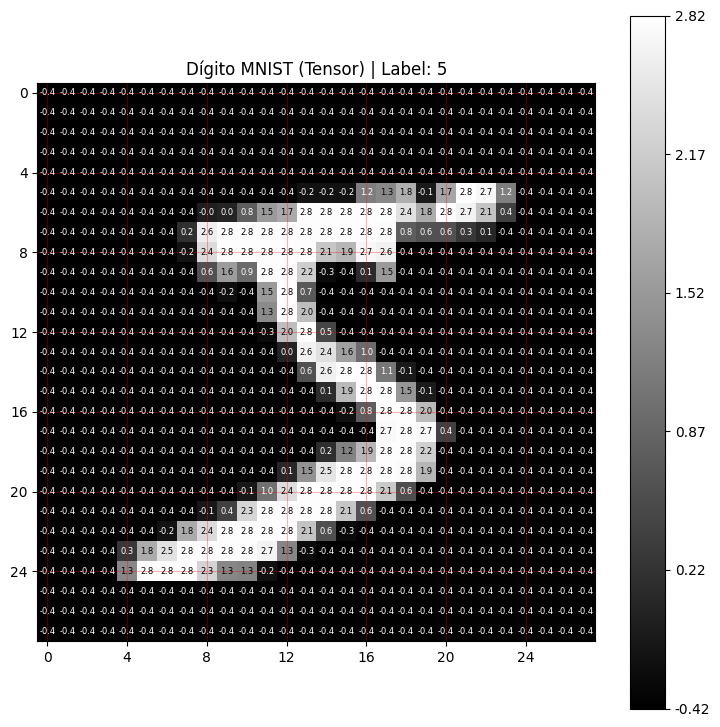

In [11]:
# Visualiza a imagem já transformada em tensor e seu respectivo rótulo.
# Com 'show_values=True', agora veremos os valores normalizados (em torno de 0) 
# em vez dos valores originais de 0 a 255, refletindo o que a rede neural realmente recebe.
helper_utils_3.display_image(image_tensor, label, "Dígito MNIST (Tensor)", show_values=True)

### Finalizando o Pipeline de Dados

Você viu como as transformações preparam suas imagens brutas para o treinamento. Agora é hora de completar o pipeline de dados criando um conjunto de dados de teste e encapsulando ambos os conjuntos com um `DataLoader`.

#### Carregar o Conjunto de Dados de Teste

Além dos dados de treinamento, você precisa de um conjunto de dados separado para testes que o modelo nunca tenha visto antes. Isso permite avaliar o quão bem o modelo se generaliza para novos exemplos.



* Você carregará o conjunto de teste usando a mesma função `torchvision.datasets.MNIST` de antes, mas com uma diferença fundamental: defina `train=False` para especificar que você deseja as 10.000 imagens de teste.

In [12]:
# Carrega o conjunto de dados MNIST para teste, aplicando o mesmo pipeline de transformações
test_dataset = torchvision.datasets.MNIST(
    root=data_path,     # Caminho para o diretório onde os dados estão ou serão baixados
    train=False,        # Define que queremos carregar especificamente os dados de TESTE (avaliação)
    download=True,      # Baixa os arquivos automaticamente se não estiverem na pasta local
    transform=transform # Aplica as mesmas transformações (ToTensor e Normalize) usadas no treino
)

#### Criar Carregadores de Dados (Data Loaders)

A etapa final do seu pipeline de dados é criar instâncias de [DataLoader](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders). Um `DataLoader` recebe o seu `Dataset` e o fornece em pedaços gerenciáveis chamados **lotes (batches)**. Isso é essencial para o treinamento em grandes conjuntos de dados, pois evita carregar todos os dados na memória de uma só vez.



* **Carregador de Treinamento (Training Loader)**: Para o conjunto de treinamento, use um `batch_size` de 64 e defina `shuffle=True`. O embaralhamento (*shuffling*) é fundamental durante o treinamento porque randomiza a ordem das amostras em cada passagem (época). Isso evita que o modelo memorize padrões baseados na ordem do conjunto de dados e ajuda-o a generalizar melhor.

* **Carregador de Teste (Test Loader)**: Para o conjunto de teste, você pode usar um tamanho de lote muito maior (por exemplo, 1000), já que os gradientes não são calculados durante a avaliação. Isso economiza memória e acelera o teste. Você definirá `shuffle=False` porque a ordem dos dados não importa quando você está apenas medindo o desempenho final do modelo.

In [13]:
# Cria um carregador de dados (DataLoader) para o conjunto de treinamento
# batch_size=64: Divide os dados em pacotes de 64 imagens por vez para otimizar o uso da memória
# shuffle=True: Embaralha os dados a cada época para garantir que o modelo não aprenda a ordem das imagens
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Cria um carregador de dados para o conjunto de teste
# batch_size=1000: Usa um lote maior para acelerar a avaliação (já que não há cálculo de gradiente)
# shuffle=False: Não é necessário embaralhar os dados de teste, pois a ordem não afeta a métrica final
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

## Construindo o Modelo de Rede Neural

Com seu pipeline de dados concluído, é hora de definir a arquitetura da rede neural. Você criará um modelo personalizado através de uma classe que herda de [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) do PyTorch. Este padrão é flexível e oferece controle total sobre a estrutura do modelo.

Toda classe `nn.Module` possui duas partes essenciais:

  * O método `__init__` é onde você define e inicializa as camadas que seu modelo usará, como se estivesse reunindo suas ferramentas antes de começar um trabalho.
  * O método `forward` é onde você define o caminho exato que os dados percorrem ao fluir através dessas camadas.

### Definir o Modelo

A arquitetura do seu modelo incluirá os seguintes componentes principais:

  * <code>[nn.Flatten()](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html)</code>: O trabalho desta camada é transformar os dados da imagem 2D (28x28 pixels) em um vetor 1D de 784 elementos ($28 \times 28 = 784$). Esta etapa de redimensionamento é necessária antes de passar os dados para as camadas lineares, que esperam vetores planos em vez de grades.

  * <code>[nn.Linear()](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)</code>: Estas são as camadas centrais da sua rede. A primeira camada linear mapeará os 784 pixels de entrada para 128 características (*features*) ocultas, e a segunda mapeará essas 128 características para 10 classes de saída, uma para cada dígito (0-9).

  * <code>[nn.ReLU()](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)</code>: Esta é a sua função de ativação. Ela introduz não linearidade, permitindo que o modelo aprenda padrões complexos que transformações lineares simples não conseguem capturar.

In [14]:
class SimpleMNISTDNN(nn.Module):
    """
    Um modelo simples de rede neural profunda (DNN) para o conjunto de dados MNIST.

    Este modelo consiste em uma camada de achatamento (flatten) seguida por duas 
    camadas lineares com uma função de ativação ReLU. Foi projetado para tarefas 
    de classificação em imagens 28x28 em tons de cinza.
    """
    def __init__(self):
        """
        Inicializa as camadas da rede neural.
        """
        super(SimpleMNISTDNN, self).__init__()
        
        # Inicializa a camada para achatar o tensor de entrada.
        # Converte a imagem de entrada de 28x28 para um vetor de 784 dimensões.
        self.flatten = nn.Flatten()
        
        # Inicializa as camadas sequenciais da rede neural
        self.layers = nn.Sequential(
            # Define a primeira camada linear com 784 entradas e 128 saídas.
            nn.Linear(784, 128),
            # Aplica a função de ativação ReLU (unidade linear retificada).
            nn.ReLU(),
            # Define a segunda camada linear com 128 entradas e 10 saídas (uma para cada dígito).
            nn.Linear(128, 10)
        )

    def forward(self, x):
        """
        Define o fluxo de passagem (forward pass) do modelo.

        Args:
            x: O tensor de entrada (imagem).

        Returns:
            O tensor de saída após passar pelas camadas da rede.
        """
        # Achata o tensor de entrada (transforma matriz em vetor).
        x = self.flatten(x)
        # Passa o tensor achatado pelas camadas sequenciais.
        x = self.layers(x)
        return x

## Treinando o Modelo

Você preparou os dados e definiu a arquitetura do modelo. No entanto, neste ponto o modelo não está treinado, portanto, suas previsões serão palpites aleatórios.

Nesta seção, você dará vida ao modelo treinando-o com os dados do MNIST. Isso envolve a configuração das ferramentas necessárias (uma função de perda e um otimizador), a definição da lógica de treinamento e avaliação, e a execução do laço (*loop*) de treinamento principal.

### Inicializar o Modelo, Função de Perda e Otimizador

Antes do treinamento, configure três componentes essenciais:

  * **O Modelo**: Primeiro, você criará uma instância da classe `SimpleMNISTDNN` que definiu anteriormente.

      * Como você viu nas aulas, é essencial que o modelo e os dados estejam no mesmo dispositivo (*device*) para evitar erros. Neste notebook, você lidará com isso dentro da própria função de treinamento. Ao mover tanto o modelo quanto os dados para o `device` dentro dessa função, você garante que eles estejam posicionados corretamente logo antes de qualquer computação ocorrer.

  * **A Função de Perda (*Loss Function*)**: Você usará <code>[nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)</code> como sua função de perda. Esta é a escolha padrão para tarefas de classificação de múltiplas classes como o MNIST, pois foi projetada especificamente para medir o erro quando um modelo precisa escolher uma classe entre várias possibilidades (ou seja, um dígito de 0 a 9).

  * **O Otimizador**: Você usará o <code>[optim.Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)</code>, um otimizador popular e altamente eficaz. O trabalho do otimizador é atualizar os pesos do modelo para minimizar a perda. O `Adam` é conhecido por adaptar a taxa de aprendizado (*learning rate*) durante o treinamento, o que geralmente ajuda o modelo a aprender de forma mais rápida e confiável do que outros otimizadores.

In [15]:
# Inicializa o modelo da rede neural definida anteriormente
model = SimpleMNISTDNN()

# Define a função de perda (loss), ideal para problemas de classificação multi-classe.
# A CrossEntropyLoss combina LogSoftmax e NLLLoss em uma única camada.
loss_function = nn.CrossEntropyLoss()

# Configura o otimizador Adam para atualizar os pesos (parâmetros) do modelo.
# O 'lr=0.001' (learning rate) define o tamanho do passo que o otimizador dá para reduzir o erro.
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Definir a Função de Treinamento

Esta função encapsula toda a lógica para uma **única época de treinamento**, que é uma passagem completa pelo conjunto de dados. Cada iteração sobre um **único lote (*batch*)** de dados dentro dessa época é chamada de **etapa (*step*)**. Como lembrete, esta função executa estas operações principais:

  * **Preparação do Modelo**: Antes de iterar sobre os dados, ela prepara o modelo movendo-o para o `device` correto e configurando-o para o modo de treinamento com `model.train()`.

  * **Laço (*Loop*) de Treinamento Principal**: Para cada lote de dados, ela executa a sequência essencial de treinamento em cinco etapas: limpar os gradientes, realizar a passagem para frente (*forward pass*), calcular a perda, realizar a retropropagação (*backpropagation*) e atualizar os pesos do modelo.



  * **Relatório de Progresso**: Por fim, ela rastreia a perda e a acurácia acumuladas, exibindo atualizações periódicas para monitorar o quão bem o modelo está aprendendo.
    * Especificamente, com **60.000** imagens de treinamento e um tamanho de lote de **64**, a função informará seu progresso a cada **134 etapas**, fornecendo **7** atualizações consistentes ao longo da época.

In [16]:
def train_epoch(model, loss_function, optimizer, train_loader, device):
    """
    Treina um modelo PyTorch por uma única época.

    Esta função itera sobre o conjunto de dados de treinamento, realiza as passagens
    para frente (forward) e para trás (backward), e atualiza os pesos do modelo.
    Também rastreia e exibe a perda (loss) e a acurácia em intervalos especificados.

    Args:
        model: O modelo de rede neural a ser treinado.
        loss_function: A função de perda usada para calcular o erro.
        optimizer: O otimizador usado para atualizar os pesos do modelo.
        train_loader: O DataLoader que fornece os lotes (batches) de dados de treino.
        device: O dispositivo (ex: 'cuda', 'mps' ou 'cpu') onde o treino será realizado.

    Returns:
        Uma tupla contendo:
        - model: O modelo após o treinamento de uma época.
        - avg_epoch_loss: A perda média calculada sobre todos os lotes da época.
    """
    # Garante que o modelo esteja no dispositivo correto (GPU ou CPU)
    model = model.to(device)
    # Define o modelo para modo de treinamento (ativa Dropout, BatchNorm, etc.)
    model.train()
    
    # Inicializa rastreadores para a perda total da época
    epoch_loss = 0.0
    
    # Inicializa rastreadores para relatórios periódicos de progresso
    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    # Itera sobre os dados de treinamento em lotes (batches)
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move o lote atual de dados para o dispositivo especificado
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Limpa os gradientes da iteração anterior para evitar acúmulo
        optimizer.zero_grad()
        
        # Realiza a passagem para frente (forward pass) para obter as previsões do modelo
        outputs = model(inputs)
        
        # Calcula a perda (erro) para o lote atual
        loss = loss_function(outputs, targets)
        
        # Realiza a retropropagação (backpropagation) para calcular os gradientes
        loss.backward()
        
        # Atualiza os pesos do modelo com base nos gradientes calculados
        optimizer.step()
        
        # Acumula a perda para fins de monitoramento
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value
        
        # Calcula métricas de acurácia para o lote atual
        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0)
        total_predictions += batch_size
        num_correct_in_batch = predicted_indices.eq(targets).sum().item()
        num_correct_predictions += num_correct_in_batch

        # Verifica se é hora de exibir uma atualização de progresso
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches:
            # Calcula a perda média e a acurácia para o intervalo atual
            avg_running_loss = running_loss / (134 if (batch_idx + 1) % 134 == 0 else (batch_idx + 1) % 134)
            accuracy = 100. * num_correct_predictions / total_predictions
            
            # Exibe a atualização de progresso
            print(f'\tPasso {batch_idx + 1}/{total_batches} - Erro: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')
            
            # Reseta os rastreadores para o próximo intervalo de relatório
            running_loss = 0.0
            num_correct_predictions = 0
            total_predictions = 0
            
    # Calcula a perda média de toda a época
    avg_epoch_loss = epoch_loss / total_batches
    # Retorna o modelo treinado e a perda média da época
    return model, avg_epoch_loss

### Definir a Função de Avaliação

Após treinar seu modelo, você precisa de uma maneira de medir seu desempenho em dados que ele nunca viu antes. Enquanto o processo de treinamento mostra o quão bem o modelo está aprendendo com os dados de treino, a função `evaluate` revela se ele consegue generalizar esse aprendizado para novos exemplos. É semelhante ao laço de treinamento, mas otimizado para inferência, com algumas diferenças fundamentais:

  * **Configuração para Inferência**: O modelo é configurado para o modo de avaliação com `model.eval()` e os cálculos de gradiente são desativados usando um bloco `torch.no_grad()`. Essas etapas são essenciais para obter resultados corretos e tornam o processo mais rápido e eficiente em termos de memória.



  * **Passagem para Frente (*Forward Pass*) Simplificada**: O laço é muito mais simples do que no treinamento. Ele apenas realiza uma passagem para frente para obter as previsões do modelo e calcular a acurácia. Não há cálculos de perda (*loss*), retropropagação (*backpropagation*) ou atualizações de peso com um otimizador.

In [17]:
def evaluate(model, test_loader, device):
    """
    Avalia a acurácia do modelo em um conjunto de dados de teste.

    Esta função coloca o modelo em modo de avaliação, itera pelos dados de teste
    e calcula a porcentagem de previsões corretas.

    Args:
        model: O modelo de rede neural a ser avaliado.
        test_loader: Um carregador de dados (DataLoader) contendo o conjunto de teste.
        device: O dispositivo (ex: 'cpu' ou 'cuda') onde a avaliação será executada.

    Returns:
        A acurácia do modelo no conjunto de teste em porcentagem.
    """
    # Define o modelo para modo de avaliação (desativa Dropout, BatchNorm, etc.)
    model.eval()
    # Inicializa um contador para as previsões corretas.
    num_correct_predictions = 0
    # Inicializa um contador para o número total de previsões realizadas.
    total_predictions = 0

    # Desativa o cálculo de gradientes para reduzir o uso de memória e acelerar a computação.
    with torch.no_grad():
        # Itera sobre todos os lotes (batches) no carregador de dados de teste.
        for inputs, targets in test_loader:
            # Move os dados de entrada e os alvos (gabarito) para o dispositivo especificado.
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Realiza a passagem para frente (forward pass) para obter a saída do modelo.
            outputs = model(inputs)
            
            # Recupera o índice do maior valor no tensor de saída, que representa a classe prevista.
            _, predicted_indices = outputs.max(1)
            
            # Obtém o tamanho do lote atual.
            batch_size = targets.size(0)
            # Soma o tamanho do lote ao total de previsões.
            total_predictions = total_predictions + batch_size
            
            # Compara os índices previstos com os valores reais dos alvos.
            correct_predictions = predicted_indices.eq(targets)
            # Soma as previsões corretas no lote atual.
            num_correct_in_batch = correct_predictions.sum().item()
            # Adiciona as previsões corretas do lote atual à contagem total.
            num_correct_predictions = num_correct_predictions + num_correct_in_batch

    # Calcula a acurácia geral como uma porcentagem.
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100
    # Exibe a acurácia calculada no console.
    print((f'\tAcurácia - {accuracy_percentage:.2f}%'))
    
    return accuracy_percentage

### O Laço de Treinamento

É aqui que todos os componentes que você construiu se unem para treinar o modelo. O laço (*loop*) é executado por um número definido de épocas, onde cada época representa uma passagem completa por todo o conjunto de dados. O treinamento por múltiplas épocas permite que o modelo veja os dados repetidamente, ajustando gradualmente seus pesos internos para melhorar a acurácia.



A lógica dentro de cada época é direta e segue um padrão padrão:

  * Primeiro, você chama a função `train_epoch` para treinar o modelo com todos os dados de treinamento.

  * Imediatamente depois, você chama a função `evaluate` para medir o desempenho do modelo nos dados de teste não vistos. Este é um passo vital para verificar se o modelo está realmente aprendendo a **generalizar** ou se está apenas memorizando o conjunto de treinamento.



Por fim, a perda (*loss*) e a acurácia de cada época são armazenadas em listas para que você possa analisar o progresso do modelo ao longo do tempo.

In [18]:
# Define o número total de épocas de treinamento (Sinta-se à vontade para alterar este número)
# Uma época significa que o modelo passará por todo o conjunto de dados uma vez.
num_epochs = 5

# Inicializa listas para armazenar as métricas de cada época para análise posterior
train_loss = []
test_acc = []

# Inicia o processo de treinamento e avaliação
for epoch in range(num_epochs):
    print(f'\n[Treinamento] Época {epoch+1}:')
    
    # Chama a função de treino para ajustar os pesos do modelo por uma época
    trained_model, loss = train_epoch(model, loss_function, optimizer, train_loader, device)
    # Armazena a perda (erro) média de treinamento desta época
    train_loss.append(loss)
    
    print(f'[Teste] Época {epoch+1}:')
    # Chama a função de avaliação para medir o desempenho no conjunto de teste (dados inéditos)
    accuracy = evaluate(trained_model, test_loader, device)
    # Armazena a acurácia de teste obtida nesta época
    test_acc.append(accuracy)


[Treinamento] Época 1:
	Passo 134/938 - Erro: 0.548 | Acc: 84.84%
	Passo 268/938 - Erro: 0.285 | Acc: 91.36%
	Passo 402/938 - Erro: 0.242 | Acc: 93.11%
	Passo 536/938 - Erro: 0.208 | Acc: 93.76%
	Passo 670/938 - Erro: 0.183 | Acc: 94.78%
	Passo 804/938 - Erro: 0.164 | Acc: 95.04%
	Passo 938/938 - Erro: 0.152 | Acc: 95.67%
[Teste] Época 1:
	Acurácia - 95.80%

[Treinamento] Época 2:
	Passo 134/938 - Erro: 0.125 | Acc: 96.40%
	Passo 268/938 - Erro: 0.114 | Acc: 96.57%
	Passo 402/938 - Erro: 0.107 | Acc: 96.75%
	Passo 536/938 - Erro: 0.110 | Acc: 96.77%
	Passo 670/938 - Erro: 0.111 | Acc: 96.71%
	Passo 804/938 - Erro: 0.105 | Acc: 96.77%
	Passo 938/938 - Erro: 0.096 | Acc: 96.98%
[Teste] Época 2:
	Acurácia - 97.26%

[Treinamento] Época 3:
	Passo 134/938 - Erro: 0.073 | Acc: 97.89%
	Passo 268/938 - Erro: 0.075 | Acc: 97.68%
	Passo 402/938 - Erro: 0.084 | Acc: 97.50%
	Passo 536/938 - Erro: 0.087 | Acc: 97.27%
	Passo 670/938 - Erro: 0.079 | Acc: 97.43%
	Passo 804/938 - Erro: 0.077 | Acc: 97.

## Analisando o Desempenho do Modelo

Com o treinamento concluído, a etapa final é analisar o desempenho do seu modelo. Você fará isso de duas maneiras: **qualitativamente**, observando algumas de suas previsões específicas, e **quantitativamente**, plotando suas métricas de desempenho ao longo do tempo.

### Visualizando Previsões

Agora que o modelo está treinado, vamos vê-lo em ação. Uma ótima maneira de ter uma noção do seu desempenho é visualizar as previsões que ele faz em amostras aleatórias do conjunto de teste. Isso permite que você veja exemplos concretos de onde o modelo acerta e onde ele pode estar cometendo erros.

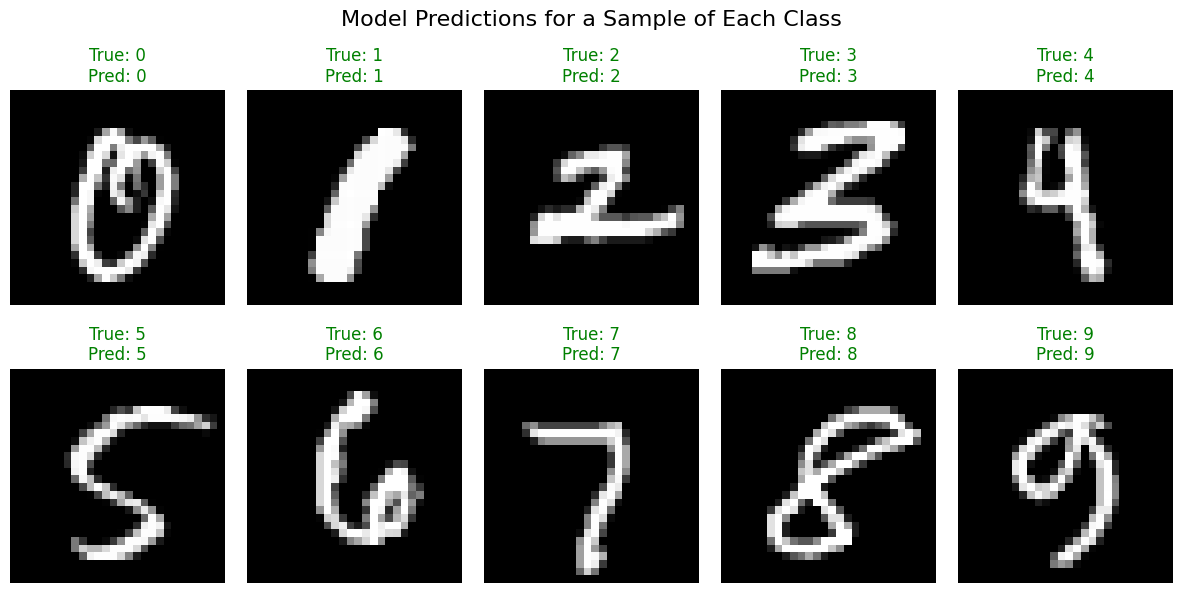

In [19]:
# Visualiza as previsões do modelo em uma amostra aleatória de imagens de teste.
# Esta função utiliza o modelo já treinado para classificar imagens que ele nunca viu,
# exibindo a imagem real ao lado da classe predita pela rede neural para validação visual.
helper_utils_3.display_predictions(trained_model, test_loader, device)

### Plotando Métricas de Desempenho

Observar previsões individuais pode ser útil, mas visualizar o desempenho geral oferece uma visão mais clara de como o treinamento progrediu. Plotar a perda (*loss*) de treinamento e a acurácia de teste ao longo das épocas ajuda você a avaliar a eficácia com que o modelo aprendeu.



  * **Perda de Treinamento (*Training Loss*)**: Este gráfico deve mostrar uma tendência constante de queda, indicando que o modelo está aprendendo com os dados de treinamento e reduzindo seu erro ao longo do tempo.

  * **Acurácia de Teste (*Test Accuracy*)**: Este gráfico deve mostrar uma tendência de alta à medida que o modelo melhora sua capacidade de generalizar para novos dados não vistos. Uma acurácia de teste crescente indica que o modelo não está apenas memorizando o conjunto de treinamento, mas está realmente aprendendo padrões que se transferem para novos exemplos. Quando a curva começa a se estabilizar (*flatten*), geralmente significa que o modelo aprendeu o máximo que podia com a configuração atual.

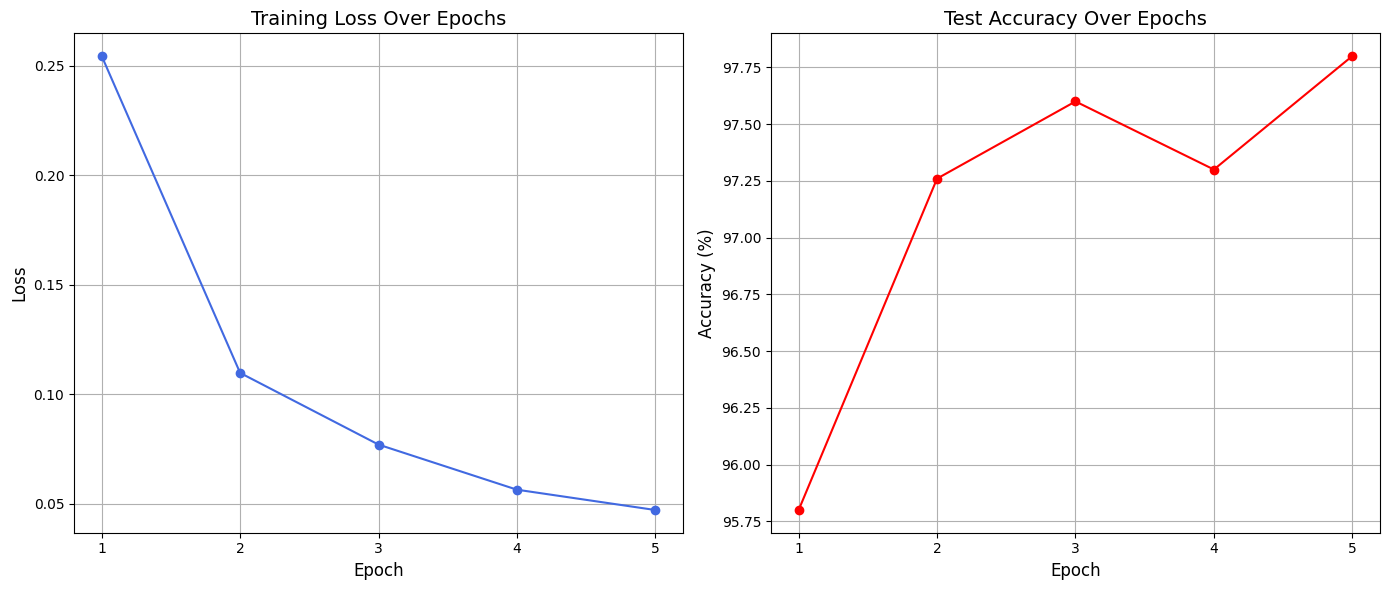

In [20]:
# Gera os gráficos das curvas de perda (loss) de treinamento e de acurácia de teste ao longo das épocas.
# Esta visualização é essencial para diagnosticar o desempenho do modelo e identificar 
# possíveis problemas como overfitting (sobreajuste) ou sobreatribuição.
helper_utils_3.plot_metrics(train_loss, test_acc)

# Conclusão

Você estudou o pipeline de aprendizado de máquina para construir, treinar e analisar seu próprio classificador de imagens.



Começou com dados de imagem brutos e viu em primeira mão por que a **preparação de dados** — transformando e normalizando suas entradas. Em seguida, construiu uma arquitetura de rede neural personalizada, praticando com o poder e a flexibilidade do **`nn.Module`**.

O mais importante é que você implementou o **laço (*loop*) de treinamento principal**, o motor que impulsiona o processo de aprendizado, e utilizou uma **função de avaliação** separada para obter uma medida honesta da capacidade do seu modelo de se generalizar para dados novos e não vistos. Os gráficos finais de perda e acurácia forneceram uma história quantitativa clara da jornada do seu modelo, desde palpites aleatórios até o reconhecimento preciso.

As habilidades que você praticou aqui formam a base para enfrentar desafios mais avançados de *deep learning* que virão pela frente.